# Imports

In [1]:
from fastai.vision.all import *
# from fastai.distributed import * #For distributing across multi GPU
# from sklearn.metrics import roc_curve, auc 
# from fastai.metrics import * 
from sklearn.model_selection import RepeatedKFold, GroupKFold, GroupShuffleSplit, \
                                    StratifiedGroupKFold, LeaveOneGroupOut, LeavePGroupsOut
from sklearn.utils import resample
import sklearn.metrics as skm
from pathlib import Path
import numpy as np
from numpy import random
import shutil
import glob
import os
import pandas as pd
from torch import cuda
import gc
import shutil
import time
from tqdm import tqdm
state = 36
scratch = os.getenv('SLURM_SCRATCH')
print(scratch)


/scratch/slurm-624923


# Import data

In [2]:
df = pd.read_csv('/ix/rbao/Projects/panCancer_HE/data/balanced_10000_sk_lu_lv_cr_df_v1_79984tiles.tsv',
                 sep = '\t')
n = 1000 #smaller dataset for debugging
df.loc[:,'tissue_anno'] = df.tissue + df.anno
df_ds = resample(df,n_samples=n,
             random_state=state, 
             replace=False,
             stratify = df.tissue_anno)
df_ds = df_ds.reset_index(drop=True)
print(df_ds.shape)
df_ds.loc[:,'scratch_fn'] = scratch + '/' + df_ds.fn.str.split('/').str[-1]
for i,fn in enumerate(tqdm(df_ds.fn.values)):
    scratch_fn = df_ds.loc[i,'scratch_fn']
    try:
        shutil.copyfile(fn,scratch_fn)
    except:
        print(scratch_fn,'Copy Failed')
print(df_ds.scratch_fn.isna().sum(),'missing')
df_ds.groupby(['tissue','anno'])['fn'].count()

(1000, 8)


100%|██████████| 1000/1000 [00:34<00:00, 28.88it/s]

0 missing


tissue      anno    
colorectal  Tumor       125
            notTumor    125
liver       Tumor       125
            notTumor    125
lung        Tumor       125
            notTumor    125
skin        Tumor       125
            notTumor    125
Name: fn, dtype: int64

# Show 36 training examples

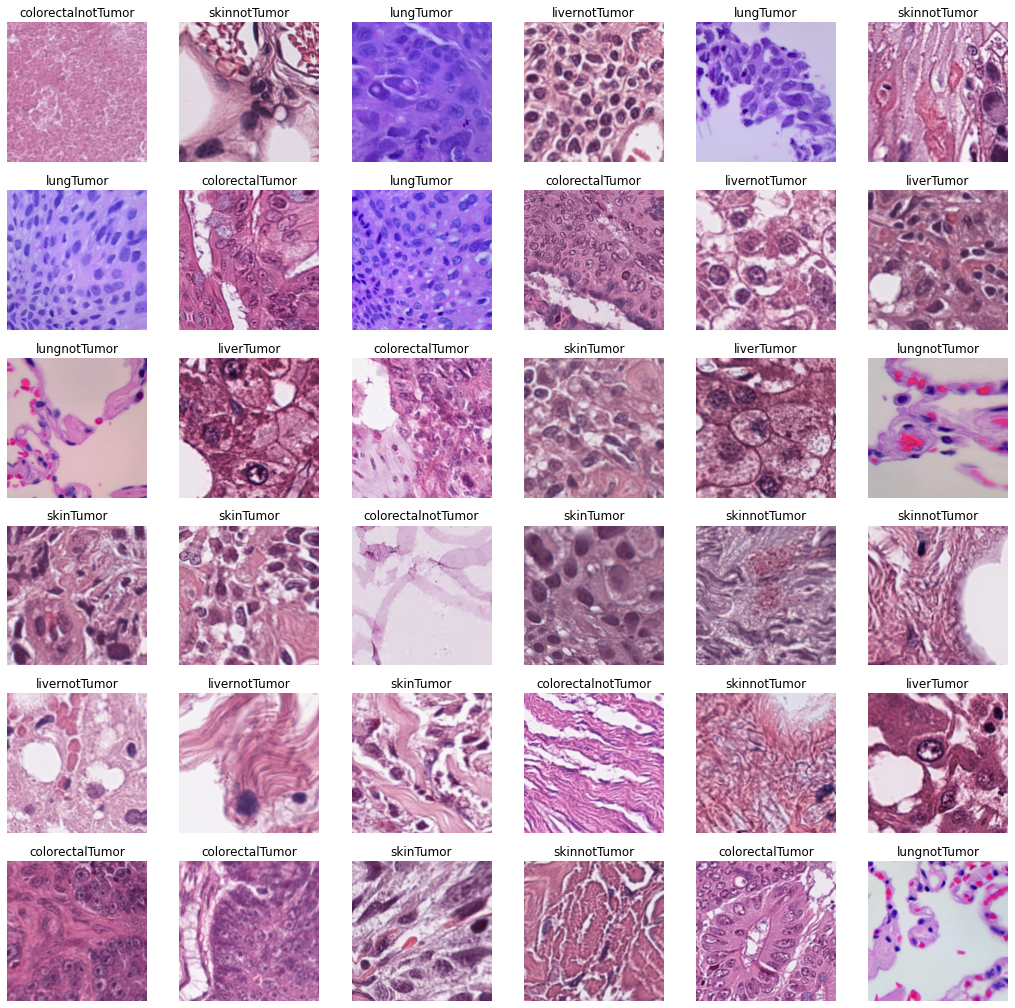

In [5]:
state = 36
splitter = TrainTestSplitter(test_size=0.1, random_state=state, stratify=df_ds.tissue_anno.values,
                    train_size=None, shuffle=True)
batch_size = 200 #5000 seemed too high, resnet18->1000-2000 works, smaller for larger models
                #32 for densenet121 seems to be more predictable w/ learning rates..
                #32 works for densenet169, 128 works, 512 does not work
tissue =DataBlock(blocks=(ImageBlock, CategoryBlock),
                  get_x=ColReader('scratch_fn'),
                  splitter=splitter,
                  get_y=  ColReader('tissue_anno'),
                  item_tfms=Resize(460), #Presize
                  batch_tfms=aug_transforms(size=224,
                                            max_rotate=45, # size=224,
                                            min_scale=1,
                                            max_zoom=0,
                                            flip_vert=True,
                                           )
                             ) 
dls = tissue.dataloaders(df_ds, bs = batch_size)
dls.show_batch(max_n=36)